# DeepLOB：公开 LOBSTER 替代数据训练

## TL;DR

本实验用 LOBSTER 公布的 5 个 NASDAQ 十档样例（AAPL、AMZN、GOOG、INTC、MSFT，2012-06-21）训练 DeepLOB，并保存可继续训练的 checkpoint。这不是论文一年 LSE 数据的复现。留出测试与 7709 零样本迁移指标均从已执行脚本产生的 JSON 读取。

In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'analysis':
    ROOT = ROOT.parent
CHECKPOINT = ROOT / 'checkpoints/deeplob_lobster_5stocks_best.pt'
TRAIN_RESULTS = ROOT / 'output/results/lobster_5stocks_training.json'
TRANSFER_RESULTS = ROOT / 'output/results/lobster_to_7709_zero_shot.json'
MATCHED_RESULTS = ROOT / 'output/results/lobster_to_7709_matched_fi_labels.json'
FI_RESULTS = ROOT / 'output/results/fi2010_to_7709_zero_shot.json'
print('project:', ROOT)
print('checkpoint:', CHECKPOINT, CHECKPOINT.exists())

project: /Users/jiaqianxing/Documents/GitHub/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books
checkpoint: /Users/jiaqianxing/Documents/GitHub/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/checkpoints/deeplob_lobster_5stocks_best.pt True


## Context & Methods

- 数据：LOBSTER 官方样例页列出的 5 个 10 档 NASDAQ 样例；下载使用公开 Hugging Face 镜像，并记录 SHA-256。
- 切分：每只股票按时间顺序 70%/15%/15%，窗口和预测目标不得跨切分。
- 输入：连续 100 个盘口事件；目标每 20 个事件抽取一次以减少高度重叠。
- 预处理：价格转为相对当前中间价的 basis points，数量取 `log1p`；z-score 只拟合训练段。
- 标签：未来 100 个事件的平均中间价相对当前中间价（DeepLOB Equation 3）；阈值只由训练目标拟合。
- 训练：AdamW、类别加权交叉熵、按验证损失保存最佳 checkpoint。

In [2]:
# 全新环境下可复跑；已有 checkpoint 时避免重复耗时训练。
if not CHECKPOINT.exists() or not TRAIN_RESULTS.exists():
    subprocess.run([
        'uv', 'run', '--python', '3.12', 'train_lobster_samples.py',
        '--epochs', '5', '--batch-size', '256', '--sample-stride', '20', '--patience', '2'
    ], cwd=ROOT, check=True)
else:
    print('Using completed training artifacts; delete them to retrain.')

Using completed training artifacts; delete them to retrain.


## Data quality

In [3]:
train = json.loads(TRAIN_RESULTS.read_text())
quality = pd.DataFrame(train['data_quality'])[[
    'symbol', 'rows', 'columns', 'invalid_rows_removed', 'finite',
    'best_ask_strictly_above_best_bid', 'ask_levels_monotone', 'bid_levels_monotone'
]]
quality

,symbol,rows,columns,invalid_rows_removed,finite,best_ask_strictly_above_best_bid,ask_levels_monotone,bid_levels_monotone
0,AAPL,400391,40,0,True,True,True,True
1,AMZN,269748,40,0,True,True,True,True
2,GOOG,147916,40,0,True,True,True,True
3,INTC,624040,40,0,True,True,True,True
4,MSFT,668765,40,0,True,True,True,True


所有保留行均为有限数值、严格非交叉盘口，且 10 档 ask/bid 价格顺序正确。下表中的样本数是应用 `sample_stride=20` 后的训练目标数，不是原始行数。

In [4]:
pd.DataFrame({
    split: values['counts']
    for split, values in train['label_summaries'].items()
}, index=['down', 'stationary', 'up']).T

,down,stationary,up
train,24104,27911,21818
validation,4771,6764,4249
test,4651,6857,4276


## Results

In [5]:
comparison = pd.DataFrame([
    {
        'dataset': 'LOBSTER holdout',
        'model': 'DeepLOB',
        'accuracy': train['test']['accuracy'],
        'balanced_accuracy': train['test']['balanced_accuracy'],
        'macro_f1': train['test']['macro_f1'],
    },
    {
        'dataset': 'LOBSTER holdout',
        'model': 'majority baseline',
        'accuracy': train['majority_baseline']['accuracy'],
        'balanced_accuracy': train['majority_baseline']['balanced_accuracy'],
        'macro_f1': train['majority_baseline']['macro_f1'],
    },
])
transfer = json.loads(TRANSFER_RESULTS.read_text())
if MATCHED_RESULTS.exists() and FI_RESULTS.exists():
    matched = json.loads(MATCHED_RESULTS.read_text())
    fi = json.loads(FI_RESULTS.read_text())
    comparison = pd.concat([comparison, pd.DataFrame([
        {
            'dataset': 'HK 7709 matched labels',
            'model': 'FI-2010 checkpoint',
            'accuracy': fi['model']['accuracy'],
            'balanced_accuracy': fi['model']['balanced_accuracy'],
            'macro_f1': fi['model']['macro_f1'],
        },
        {
            'dataset': 'HK 7709 matched labels',
            'model': 'LOBSTER checkpoint',
            'accuracy': matched['model']['accuracy'],
            'balanced_accuracy': matched['model']['balanced_accuracy'],
            'macro_f1': matched['model']['macro_f1'],
        },
    ])], ignore_index=True)
comparison.style.format({c: '{:.2%}' for c in ['accuracy', 'balanced_accuracy', 'macro_f1']})

,dataset,model,accuracy,balanced_accuracy,macro_f1
0,LOBSTER holdout,DeepLOB,66.75%,63.11%,59.25%
1,LOBSTER holdout,majority baseline,43.44%,33.33%,20.19%
2,HK 7709 matched labels,FI-2010 checkpoint,30.42%,31.84%,23.10%
3,HK 7709 matched labels,LOBSTER checkpoint,34.89%,33.94%,25.51%


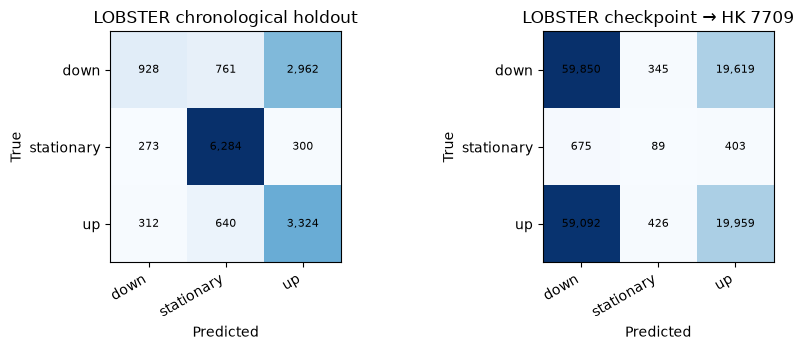

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, key, title in zip(
    axes,
    ['test', 'transfer'],
    ['LOBSTER chronological holdout', 'LOBSTER checkpoint → HK 7709'],
):
    matrix = train['test']['confusion_matrix'] if key == 'test' else transfer['model']['confusion_matrix']
    image = ax.imshow(matrix, cmap='Blues')
    ax.set(title=title, xlabel='Predicted', ylabel='True', xticks=range(3), yticks=range(3))
    ax.set_xticklabels(['down', 'stationary', 'up'], rotation=30, ha='right')
    ax.set_yticklabels(['down', 'stationary', 'up'])
    for i, row in enumerate(matrix):
        for j, value in enumerate(row):
            ax.text(j, i, f'{value:,}', ha='center', va='center', fontsize=8)
fig.tight_layout()
plt.show()

## Takeaways

1. checkpoint 在同源、严格时间留出的 LOBSTER 测试段明显优于多数类基线，证明训练管线和权重文件可用。
2. 在与 FI-2010 checkpoint 完全相同的 7709 评估区间和标签上，LOBSTER checkpoint 的 Accuracy / Balanced Accuracy / Macro-F1 均略高，但绝对水平仍低。
3. 按 LOBSTER 自身的零阈值标签迁移到 7709 后，模型明显偏向预测 down；公开 NASDAQ 单日样例不能直接解决港股域偏移。
4. 该 checkpoint 适合作为下一步微调/迁移学习的初始化权重，不应当作为可直接交易的 7709 模型。
5. 最重要限制：5 只股票来自同一天，归一化也因缺少前 5 个交易日而不同于论文。